# Consistency-sweep analysis — `rescience_c` corpus across models × temperatures

Inputs come from `data/experiments/consistency_checks/rescience_c/`:

- `run_timings.csv` — one row per `(paper, model, temperature, sample)` cell with `status`, `duration_seconds`, and an `output_path` pointing at the profile JSON.
- `<stem>.profile.json` for each successful run (current schema: `metadata + nodes_source + nodes_process + nodes_sink`).
- `<stem>.profile.err.txt` sidecars for failures.

The corpus contains 10 ReScience-C papers (`2017_01_article` … `2025_03_article`) extracted with `gemini-2.5-flash` and `gemini-2.5-pro`. Aggregations below pool over papers; sections cover (1) failures by model × temperature, (2) execution time per model, (3) node counts (`nodes_source` / `nodes_process` / `nodes_sink`), (4) reproducibility index plus its **structural** and **content** components, computed exactly as in `workflow_graph_analysis.ipynb` §5.


In [1]:
import json
import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

DATA_DIR = Path("data/experiments/consistency_checks/rescience_c")
TIMING_CSVS = [DATA_DIR / "run_timings.csv"]

# --- Nature-style figure conventions ---------------------------------------
# Single-column width = 89 mm ~ 3.5 in, double-column ~ 7.2 in. Sans-serif
# Arial fallback, hairline strokes, embedded TrueType fonts (pdf.fonttype=42),
# no top/right spines, dotted y-grid only, Okabe-Ito colour-blind palette.
NATURE_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelsize": 7,
    "axes.labelcolor": "#222",
    "axes.edgecolor": "#444",
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "xtick.color": "#444",
    "ytick.color": "#444",
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "legend.fontsize": 6,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "lines.linewidth": 0.9,
    "patch.linewidth": 0.6,
}
plt.rcParams.update(NATURE_RC)

# Okabe-Ito colour-blind-safe categorical palette.
OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00",
             "#56B4E9", "#CC79A7", "#F0E442", "#000000"]
_model_color_map: dict[str, str] = {}


def model_color(name: str) -> str:
    if name not in _model_color_map:
        _model_color_map[name] = OKABE_ITO[len(_model_color_map) % len(OKABE_ITO)]
    return _model_color_map[name]


def style_axes(ax, *, ygrid: bool = True) -> None:
    ax.spines["left"].set_color("#444")
    ax.spines["bottom"].set_color("#444")
    ax.tick_params(axis="both", which="both", direction="out", length=2.5, width=0.6, colors="#444")
    if ygrid:
        ax.yaxis.grid(True, linestyle=":", linewidth=0.4, color="#bbbbbb", alpha=0.9)
        ax.set_axisbelow(True)
    ax.xaxis.grid(False)


def nature_box(ax, data, labels, *, colors=None, jitter=True, widths=0.55, ymin=None, ymax=None):
    """Boxplot with thin coloured boxes, median line, mean cross, and optional point overlay."""
    if colors is None:
        colors = ["#888"] * len(data)
    bp = ax.boxplot(
        data,
        tick_labels=labels,
        widths=widths,
        showmeans=True,
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color="#111", linewidth=1.0),
        whiskerprops=dict(color="#444", linewidth=0.6),
        capprops=dict(color="#444", linewidth=0.6),
        boxprops=dict(linewidth=0.6),
        meanprops=dict(marker="x", markerfacecolor="#111",
                       markeredgecolor="#111", markersize=4, markeredgewidth=0.8),
    )
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
        patch.set_edgecolor("#222")
    if jitter:
        rng = np.random.default_rng(0)
        for i, (vals, c) in enumerate(zip(data, colors), start=1):
            if len(vals) == 0:
                continue
            xs = rng.normal(loc=i, scale=0.04, size=len(vals))
            ax.scatter(xs, vals, s=3.0, color=c, edgecolor="#222",
                       linewidths=0.2, alpha=0.6, zorder=3)
    ax.tick_params(axis="x", rotation=20)
    style_axes(ax)
    if ymin is not None or ymax is not None:
        ax.set_ylim(ymin, ymax)
    return bp


## 1. Load timings

Concatenate both CSVs, normalise temperature to float, and extract the `ExceptionType` from the `err:<Type>` status.

In [2]:
frames = [pd.read_csv(p) for p in TIMING_CSVS if p.exists()]
timings = pd.concat(frames, ignore_index=True)
timings["temperature"] = timings["temperature"].astype(float)
timings["status"] = timings["status"].fillna("")
timings["ok"] = timings["status"] == "ok"
timings["error_type"] = timings["status"].apply(
    lambda s: s.split(":", 1)[1] if s.startswith("err:") else ""
)

MODELS = sorted(timings.model.unique())
TEMPS = sorted(timings.temperature.unique())
print(f"rows: {len(timings)}   models: {MODELS}   temps: {TEMPS}")
timings.groupby(["model", "ok"]).size().unstack(fill_value=0).rename(columns={True: "ok", False: "err"})

rows: 2000   models: ['gemini-2.5-flash', 'gemini-2.5-pro', 'gemini-3-flash-preview', 'gemini-3.1-pro-preview']   temps: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0)]


ok,err,ok
model,,
gemini-2.5-flash,134,366
gemini-2.5-pro,36,464
gemini-3-flash-preview,17,483
gemini-3.1-pro-preview,9,491


## 2. Failures by model and temperature

Counts of `err:*` rows and the corresponding fail rate. The Qwen and Gemini grids do not overlap in temperature — empty cells stay blank.

In [3]:
fail = (
    timings.assign(failed=lambda d: (~d.ok).astype(int))
    .groupby(["model", "temperature"])
    .agg(n_failed=("failed", "sum"), n_runs=("failed", "count"))
)
fail["fail_rate"] = fail["n_failed"] / fail["n_runs"]
fail.round(3)

n_failed  n_runs  fail_rate
model                  temperature                             
gemini-2.5-flash       0.0                23     100       0.23
                       0.5                19     100       0.19
                       1.0                19     100       0.19
                       1.5                41     100       0.41
                       2.0                32     100       0.32
gemini-2.5-pro         0.0                 9     100       0.09
                       0.5                 5     100       0.05
                       1.0                 6     100       0.06
                       1.5                11     100       0.11
                       2.0                 5     100       0.05
gemini-3-flash-preview 0.0                 6     100       0.06
                       0.5                 1     100       0.01
                       1.0                 2     100       0.02
                       1.5                 5     100       0.05
                       2.0                 3     100       0.03
gemini-3.1-pro-preview 0.0                 4     100       0.04
                       0.5                 1     100       0.01
                       1.0                 0     100       0.00
                       1.5                 0     100       0.00
                       2.0                 4     100       0.04

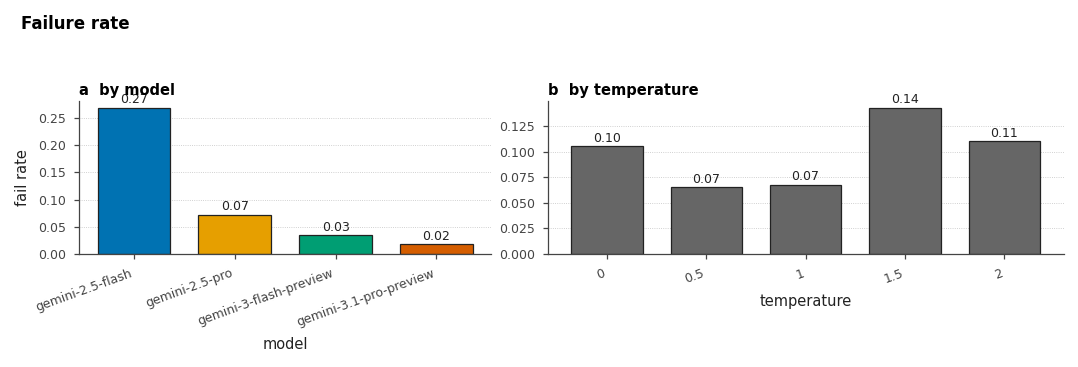

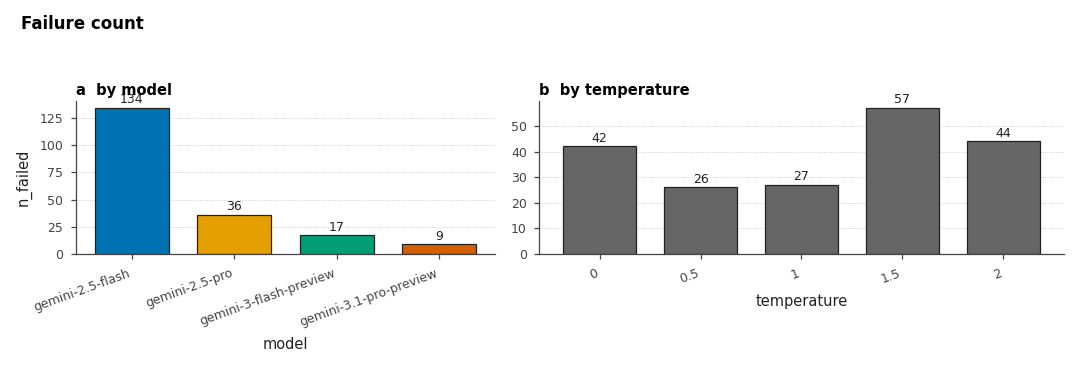

In [4]:
def nature_bars(ax, series, *, colors=None, fmt="{:.2f}", value_label=True, ylim=None):
    """Vertical bar chart with hairline edges and value labels above each bar."""
    x = np.arange(len(series))
    if colors is None:
        colors = ["#0072B2"] * len(series)
    bars = ax.bar(x, series.values, color=colors, edgecolor="#222",
                  linewidth=0.6, width=0.72)
    ax.set_xticks(x)
    labels = [f"{i:g}" if isinstance(i, (int, float, np.floating)) else str(i)
              for i in series.index]
    ax.set_xticklabels(labels, rotation=20, ha="right")
    if value_label:
        ymax_data = np.nanmax(series.values) if len(series) else 1.0
        offset = 0.012 * (ymax_data if ymax_data > 0 else 1.0)
        for b, v in zip(bars, series.values):
            if pd.isna(v):
                continue
            ax.text(b.get_x() + b.get_width() / 2, v + offset,
                    fmt.format(v), ha="center", va="bottom",
                    fontsize=6, color="#222")
    style_axes(ax)
    if ylim is not None:
        ax.set_ylim(*ylim)
    return bars


def paired_bars(by_model, by_temp, title, *, fmt="{:.2f}", ylabel="",
                ylim=None, temp_color="#666666"):
    """Two-panel bar chart: aggregated by model | aggregated by temperature."""
    fig, axes = plt.subplots(
        1, 2, figsize=(7.2, 2.4),
        gridspec_kw={"width_ratios": [max(1, len(by_model)),
                                      max(1, len(by_temp))]},
    )
    nature_bars(axes[0], by_model,
                colors=[model_color(m) for m in by_model.index],
                fmt=fmt, ylim=ylim)
    nature_bars(axes[1], by_temp,
                colors=[temp_color] * len(by_temp),
                fmt=fmt, ylim=ylim)
    axes[0].set_ylabel(ylabel)
    axes[0].set_xlabel("model")
    axes[1].set_xlabel("temperature")
    axes[0].set_title("a  by model", fontsize=7, pad=3)
    axes[1].set_title("b  by temperature", fontsize=7, pad=3)
    fig.suptitle(title, x=0.02, ha="left", fontsize=8, fontweight="bold")
    plt.tight_layout(rect=(0, 0, 1, 0.93))
    return fig, axes


# Weighted failure rate = sum(n_failed) / sum(n_runs) per group.
_fail = timings.assign(failed=(~timings.ok).astype(int))
fail_by_model = _fail.groupby("model").agg(
    n_failed=("failed", "sum"), n_runs=("failed", "count"))
fail_by_model["fail_rate"] = fail_by_model.n_failed / fail_by_model.n_runs

fail_by_temp = _fail.groupby("temperature").agg(
    n_failed=("failed", "sum"), n_runs=("failed", "count"))
fail_by_temp["fail_rate"] = fail_by_temp.n_failed / fail_by_temp.n_runs

paired_bars(fail_by_model["fail_rate"], fail_by_temp["fail_rate"],
            "Failure rate", fmt="{:.2f}", ylabel="fail rate", ylim=(0, None))
plt.show()

paired_bars(fail_by_model["n_failed"], fail_by_temp["n_failed"],
            "Failure count", fmt="{:.0f}", ylabel="n_failed", ylim=(0, None))
plt.show()


In [5]:
err_break = timings[~timings.ok].groupby(["model", "error_type"]).size().unstack(fill_value=0)
print("failure types per model:")
print(err_break)

failure types per model:
error_type              RuntimeError  ServerError  ValidationError
model                                                             
gemini-2.5-flash                   1            3              130
gemini-2.5-pro                     0           33                3
gemini-3-flash-preview            11            3                3
gemini-3.1-pro-preview             1            6                2


## 3. Execution time per model

Distribution over all `ok` rows; the table also reports per-cell median runtime so the slow Qwen-vs-fast Gemini gap is explicit.

In [6]:
ok = timings[timings.ok].copy()
summary = (
    ok.groupby("model")["duration_seconds"]
    .agg(n="count", mean="mean", median="median", std="std", p90=lambda s: s.quantile(0.9))
    .round(1)
)
summary

,n,mean,median,std,p90
model,,,,,
gemini-2.5-flash,366,200.5,182.8,119.7,269.4
gemini-2.5-pro,464,176.4,169.6,44.9,236.7
gemini-3-flash-preview,483,217.8,141.4,180.6,553.5
gemini-3.1-pro-preview,491,365.5,318.4,166.5,604.2


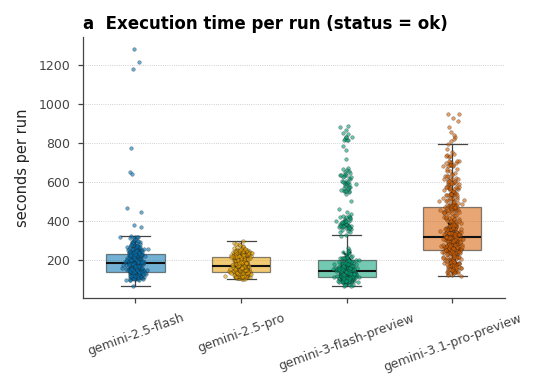

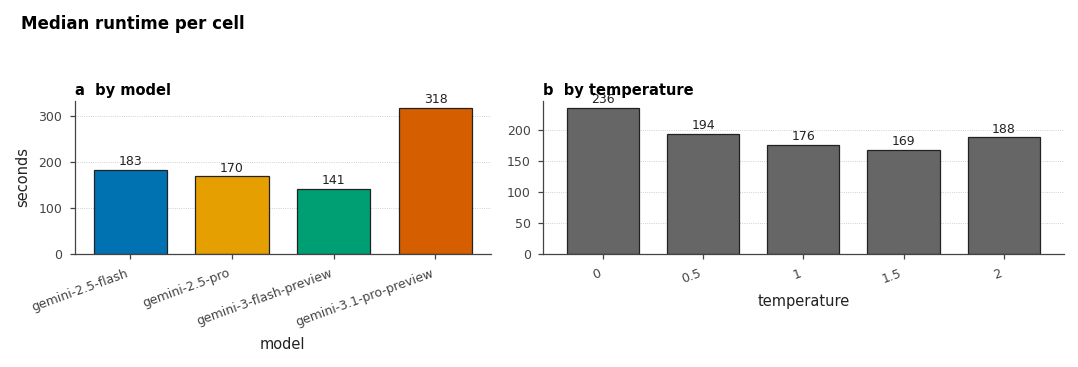

In [7]:
fig, ax = plt.subplots(figsize=(3.6, 2.6))
data = [ok[ok.model == m]["duration_seconds"].values for m in MODELS]
nature_box(ax, data, MODELS, colors=[model_color(m) for m in MODELS])
ax.set_ylabel("seconds per run")
ax.set_title("a  Execution time per run (status = ok)", pad=4)
plt.tight_layout()
plt.show()

rt_by_model = ok.groupby("model")["duration_seconds"].median()
rt_by_temp = ok.groupby("temperature")["duration_seconds"].median()
paired_bars(rt_by_model, rt_by_temp,
            "Median runtime per cell",
            fmt="{:.0f}", ylabel="seconds")
plt.show()


## 4. Node counts across runs

Load every successful profile, then count `nodes_source`, `nodes_process`, and `nodes_sink`. Per-step process types (`method` vs `experiment`) are captured separately.

In [8]:
def _norm(s: str) -> str:
    return " ".join(str(s).lower().split())


def _process_id(s: dict, idx: int) -> str:
    nid = s.get("node_id")
    if isinstance(nid, str) and nid:
        return nid
    o = s.get("order", idx + 1)
    try:
        return f"meth_{int(o):02d}"
    except (TypeError, ValueError):
        return f"meth_{idx + 1:02d}"


def _process_inputs(s: dict) -> list[str]:
    return list(s.get("input_ids") or s.get("data_inputs") or [])


def _process_outcomes(s: dict) -> list[str]:
    return list(s.get("outcomes") or s.get("expected_outputs") or [])


def build_graph(profile: dict) -> nx.DiGraph:
    """Same construction rule as workflow_graph_analysis.ipynb §2."""
    g = nx.DiGraph()
    src_ids = set()
    for s in profile.get("nodes_source", []):
        sid = s["node_id"]
        src_ids.add(sid)
        g.add_node(sid, layer="source")
    sink_ids = set()
    for s in profile.get("nodes_sink", []):
        sid = s["node_id"]
        sink_ids.add(sid)
        g.add_node(sid, layer="sink")
    procs = []
    for idx, s in enumerate(profile.get("nodes_process", [])):
        mid = _process_id(s, idx)
        ins = [_norm(x) for x in _process_inputs(s)]
        outs = [_norm(x) for x in _process_outcomes(s)]
        g.add_node(mid, layer="process", input_ids=ins, outcomes=outs)
        procs.append((mid, ins, outs))
    for mid, ins, outs in procs:
        for lbl in ins:
            if lbl in src_ids:
                g.add_edge(lbl, mid)
        for lbl in outs:
            if lbl in sink_ids:
                g.add_edge(mid, lbl)
    for i, (mi, _, outs_i) in enumerate(procs):
        outs_set = set(outs_i) - src_ids - sink_ids
        if not outs_set:
            continue
        for j, (mj, ins_j, _) in enumerate(procs):
            if i == j:
                continue
            if outs_set & set(ins_j):
                g.add_edge(mi, mj)
    return g


def wiring_metrics(g: nx.DiGraph) -> dict:
    by = {l: [v for v, d in g.nodes(data=True) if d["layer"] == l] for l in ("source", "process", "sink")}
    src, proc, snk = by["source"], by["process"], by["sink"]
    src_used = sum(1 for v in src if g.out_degree(v) > 0)
    snk_made = sum(1 for v in snk if g.in_degree(v) > 0)
    all_outs = set()
    for v in proc:
        all_outs.update(g.nodes[v]["outcomes"])
    src_ids, sink_ids = set(src), set(snk)
    known = src_ids | sink_ids | all_outs
    tot_in = dangling = 0
    for v in proc:
        for lbl in g.nodes[v]["input_ids"]:
            tot_in += 1
            if lbl not in known:
                dangling += 1
    if src and snk:
        reach = sum(nx.has_path(g, s, t) for s in src for t in snk) / (len(src) * len(snk))
    else:
        reach = 0.0
    n = g.number_of_nodes()
    lwcc = max((len(c) for c in nx.weakly_connected_components(g)), default=0) / max(1, n)
    return {
        "sources_consumed_ratio": (src_used / len(src)) if src else 0.0,
        "sinks_produced_ratio": (snk_made / len(snk)) if snk else 0.0,
        "resolved_input_ratio": (1 - dangling / tot_in) if tot_in else 0.0,
        "source_to_sink_reachability": reach,
        "lwcc_fraction": lwcc,
    }


def structural_score(w: dict) -> float:
    return (
        0.25 * w["sources_consumed_ratio"]
        + 0.25 * w["sinks_produced_ratio"]
        + 0.20 * w["resolved_input_ratio"]
        + 0.15 * w["source_to_sink_reachability"]
        + 0.15 * w["lwcc_fraction"]
    )


LAYER_W = {"source": 0.30, "process": 0.40, "sink": 0.30}


def content_score(profile: dict) -> tuple[float, dict]:
    def layer_mean(items):
        if not items:
            return None
        scores = [int(it.get("reproducibility_score", 0)) for it in items]
        return sum(scores) / len(scores) / 100.0

    layer = {
        "source": layer_mean(profile.get("nodes_source", [])),
        "process": layer_mean(profile.get("nodes_process", [])),
        "sink": layer_mean(profile.get("nodes_sink", [])),
    }
    present = {k: v for k, v in layer.items() if v is not None}
    if not present:
        return 0.0, layer
    tw = sum(LAYER_W[k] for k in present)
    return sum(LAYER_W[k] * v / tw for k, v in present.items()), layer

In [9]:
rows = []
missing = 0
for _, r in ok.iterrows():
    candidates = [Path(r["output_path"]), DATA_DIR / Path(r["output_path"]).name]
    fp = next((c for c in candidates if c.exists()), None)
    if fp is None:
        missing += 1
        continue
    p = json.loads(fp.read_text())
    g = build_graph(p)
    w = wiring_metrics(g)
    s = structural_score(w)
    c, layer = content_score(p)
    n_method = sum(1 for x in p.get("nodes_process", []) if x.get("process_type") == "method")
    n_exp = sum(1 for x in p.get("nodes_process", []) if x.get("process_type") == "experiment")
    rows.append({
        "paper": r["paper"],
        "model": r["model"],
        "temperature": float(r["temperature"]),
        "sample": int(r["sample"]),
        "n_source": len(p.get("nodes_source", [])),
        "n_process": len(p.get("nodes_process", [])),
        "n_method": n_method,
        "n_experiment": n_exp,
        "n_sink": len(p.get("nodes_sink", [])),
        "structural": s,
        "content": c,
        "repro_index": math.sqrt(max(0.0, s) * max(0.0, c)),
        "src_repro": layer["source"],
        "proc_repro": layer["process"],
        "sink_repro": layer["sink"],
        **w,
    })
df = pd.DataFrame(rows)
print(f"profiles loaded: {len(df)}   missing on disk: {missing}")
df.head()

profiles loaded: 1804   missing on disk: 0


,paper,model,temperature,sample,n_source,n_process,n_method,n_experiment,n_sink,structural,content,repro_index,src_repro,proc_repro,sink_repro,sources_consumed_ratio,sinks_produced_ratio,resolved_input_ratio,source_to_sink_reachability,lwcc_fraction
0,2017_04_article.pdf,gemini-2.5-pro,0.5,9,1,4,3,1,1,0.5750,0.610000,0.592242,0.5,0.775000,0.5,0.0,1.0,1.0,0.0,0.833333
1,2017_04_article.pdf,gemini-2.5-pro,0.0,1,1,3,2,1,1,1.0000,0.583333,0.763763,0.5,0.633333,0.6,1.0,1.0,1.0,1.0,1.000000
2,2017_04_article.pdf,gemini-2.5-pro,0.0,6,1,2,1,1,1,1.0000,0.490000,0.700000,0.5,0.475000,0.5,1.0,1.0,1.0,1.0,1.000000
3,2017_04_article.pdf,gemini-2.5-pro,1.0,1,1,2,1,1,1,0.5625,0.570000,0.566238,0.5,0.750000,0.4,0.0,1.0,1.0,0.0,0.750000
4,2017_04_article.pdf,gemini-2.5-pro,0.5,3,1,4,3,1,1,0.5750,0.570000,0.572495,0.5,0.675000,0.5,0.0,1.0,1.0,0.0,0.833333


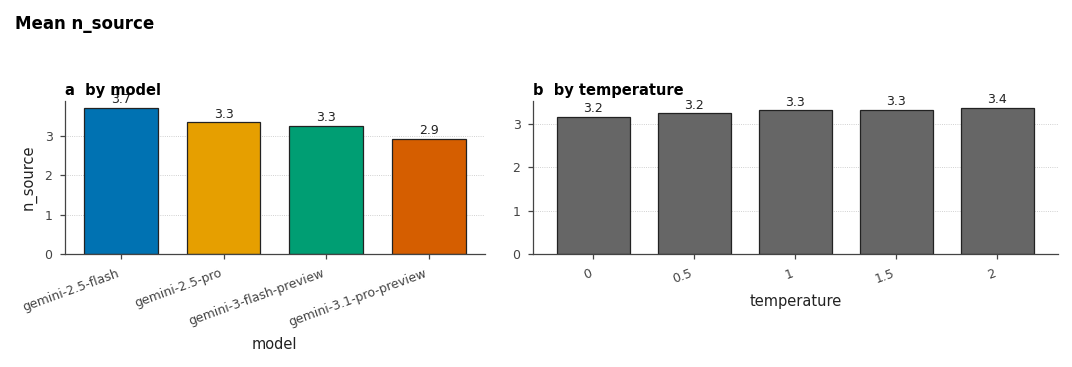

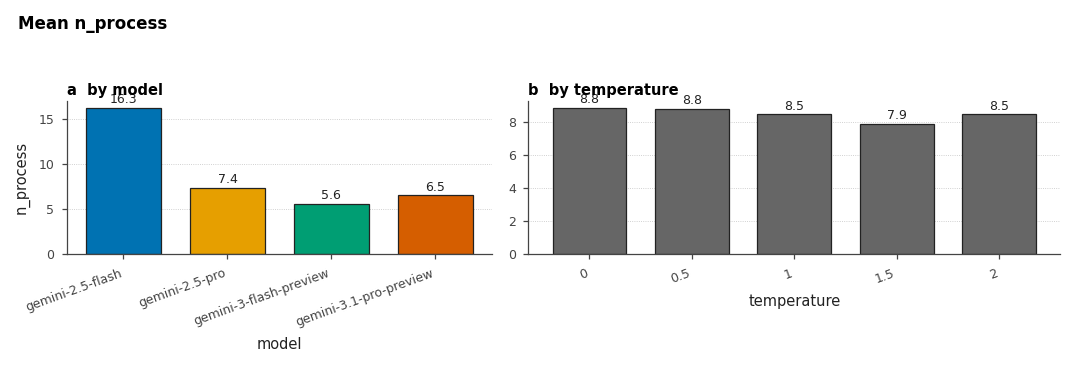

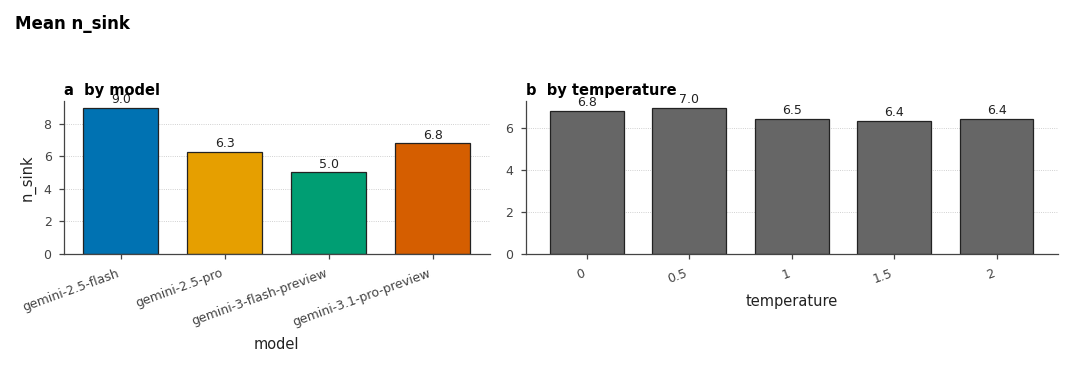

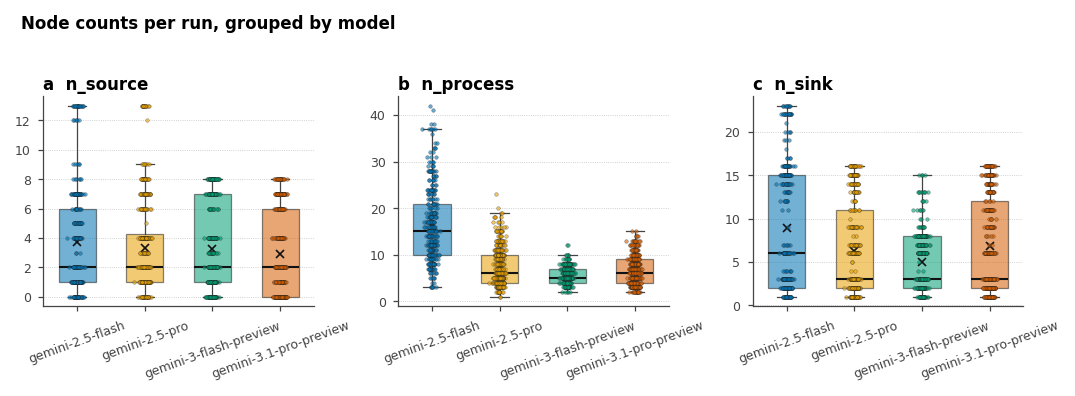

method vs experiment split per model:


,n_method,n_experiment
model,,
gemini-2.5-flash,9.56,6.72
gemini-2.5-pro,3.40,4.00
gemini-3-flash-preview,3.07,2.51
gemini-3.1-pro-preview,2.77,3.78


In [10]:
PANEL_LABELS = ["a", "b", "c"]
NODE_COLS = ["n_source", "n_process", "n_sink"]

for col in NODE_COLS:
    by_model = df.groupby("model")[col].mean()
    by_temp = df.groupby("temperature")[col].mean()
    paired_bars(by_model, by_temp,
                f"Mean {col}",
                fmt="{:.1f}", ylabel=col, ylim=(0, None))
    plt.show()

fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6))
colors = [model_color(m) for m in MODELS]
for letter, ax, col in zip(PANEL_LABELS, axes, NODE_COLS):
    nature_box(ax, [df[df.model == m][col].values for m in MODELS], MODELS, colors=colors)
    ax.set_title(f"{letter}  {col}", pad=3)
fig.suptitle("Node counts per run, grouped by model",
             x=0.02, ha="left", fontsize=8, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

print("method vs experiment split per model:")
df.groupby("model")[["n_method", "n_experiment"]].mean().round(2)


## 5. Reproducibility index — structural, content, and the geometric-mean composite

Same definition as `workflow_graph_analysis.ipynb` §5:

- **structural** = `0.25·sources_consumed_ratio + 0.25·sinks_produced_ratio + 0.20·resolved_input_ratio + 0.15·source_to_sink_reachability + 0.15·lwcc_fraction`
- **content** = layer-weighted mean of `reproducibility_score` (sources 0.30, processes 0.40, sinks 0.30), normalised to `[0, 1]`
- **repro_index** = `sqrt(structural · content)`

Per `(model, temperature)` cell, take the mean across the 10 samples.

In [11]:
agg = (
    df.groupby(["model", "temperature"])[["structural", "content", "repro_index"]]
    .agg(["mean", "std"])
    .round(3)
)
agg

structural        content         \
                                         mean    std    mean    std   
model                  temperature                                    
gemini-2.5-flash       0.0              0.767  0.170   0.751  0.147   
                       0.5              0.760  0.165   0.708  0.154   
                       1.0              0.788  0.174   0.724  0.149   
                       1.5              0.798  0.170   0.737  0.137   
                       2.0              0.821  0.177   0.739  0.145   
gemini-2.5-pro         0.0              0.816  0.171   0.669  0.161   
                       0.5              0.839  0.161   0.659  0.171   
                       1.0              0.817  0.172   0.654  0.168   
                       1.5              0.829  0.161   0.667  0.178   
                       2.0              0.823  0.169   0.635  0.183   
gemini-3-flash-preview 0.0              0.852  0.164   0.796  0.117   
                       0.5              0.849  0.161   0.806  0.121   
                       1.0              0.835  0.174   0.797  0.120   
                       1.5              0.854  0.159   0.811  0.116   
                       2.0              0.844  0.163   0.806  0.117   
gemini-3.1-pro-preview 0.0              0.785  0.159   0.783  0.125   
                       0.5              0.799  0.162   0.755  0.129   
                       1.0              0.809  0.157   0.757  0.141   
                       1.5              0.792  0.168   0.743  0.139   
                       2.0              0.785  0.171   0.729  0.144   

                                   repro_index         
                                          mean    std  
model                  temperature                     
gemini-2.5-flash       0.0               0.748  0.098  
                       0.5               0.724  0.110  
                       1.0               0.746  0.118  
                       1.5               0.759  0.116  
                       2.0               0.769  0.113  
gemini-2.5-pro         0.0               0.732  0.137  
                       0.5               0.736  0.138  
                       1.0               0.722  0.135  
                       1.5               0.733  0.131  
                       2.0               0.714  0.148  
gemini-3-flash-preview 0.0               0.818  0.106  
                       0.5               0.820  0.096  
                       1.0               0.808  0.103  
                       1.5               0.826  0.098  
                       2.0               0.818  0.098  
gemini-3.1-pro-preview 0.0               0.776  0.098  
                       0.5               0.768  0.096  
                       1.0               0.774  0.098  
                       1.5               0.757  0.097  
                       2.0               0.746  0.099

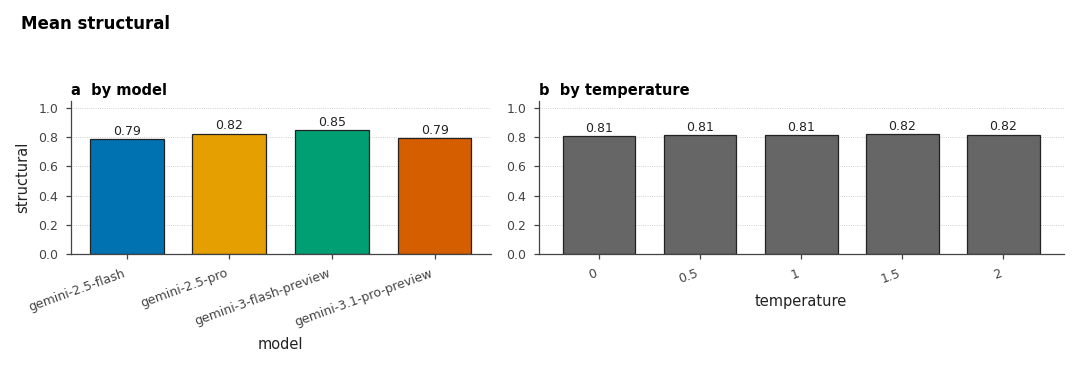

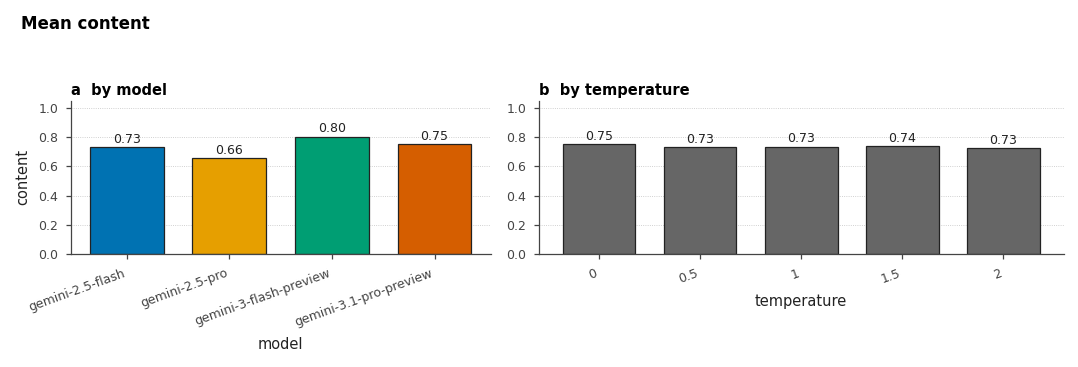

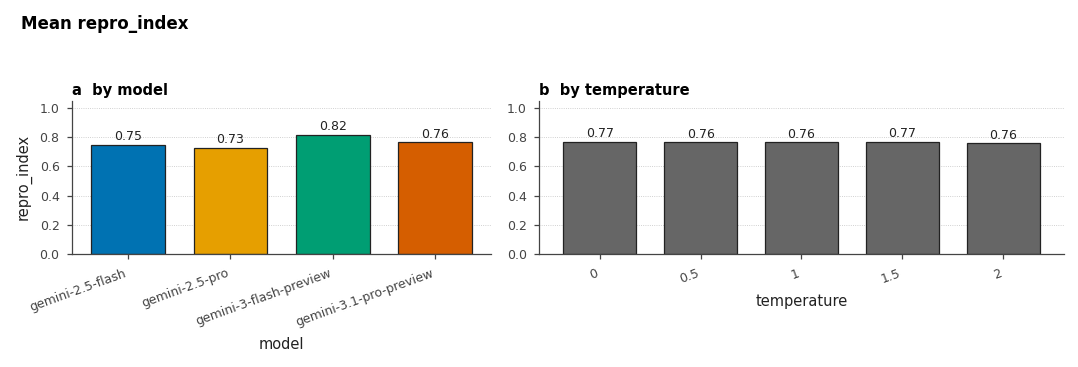

In [12]:
SCORE_COLS = ["structural", "content", "repro_index"]
for col in SCORE_COLS:
    by_model = df.groupby("model")[col].mean()
    by_temp = df.groupby("temperature")[col].mean()
    paired_bars(by_model, by_temp,
                f"Mean {col}",
                fmt="{:.2f}", ylabel=col, ylim=(0, 1.05))
    plt.show()


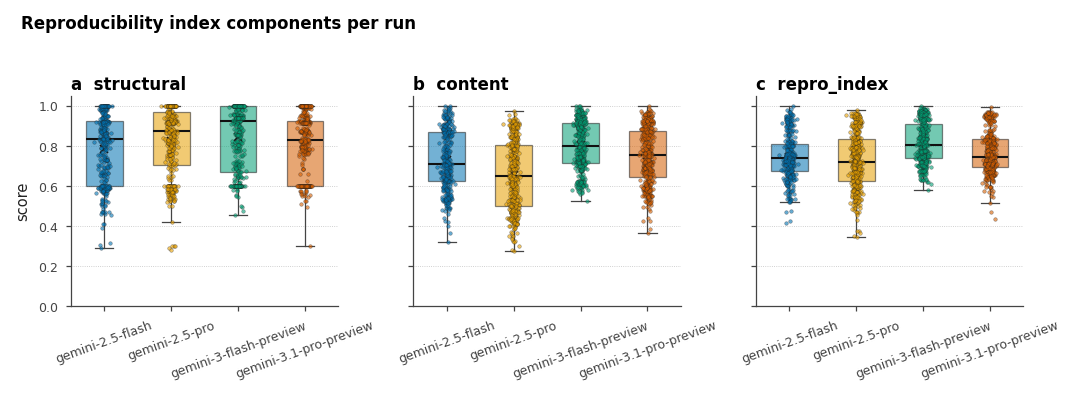

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), sharey=True)
colors = [model_color(m) for m in MODELS]
for letter, ax, col in zip(PANEL_LABELS, axes, SCORE_COLS):
    nature_box(ax, [df[df.model == m][col].values for m in MODELS], MODELS,
               colors=colors, ymin=0, ymax=1.05)
    ax.set_title(f"{letter}  {col}", pad=3)
axes[0].set_ylabel("score")
fig.suptitle("Reproducibility index components per run",
             x=0.02, ha="left", fontsize=8, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


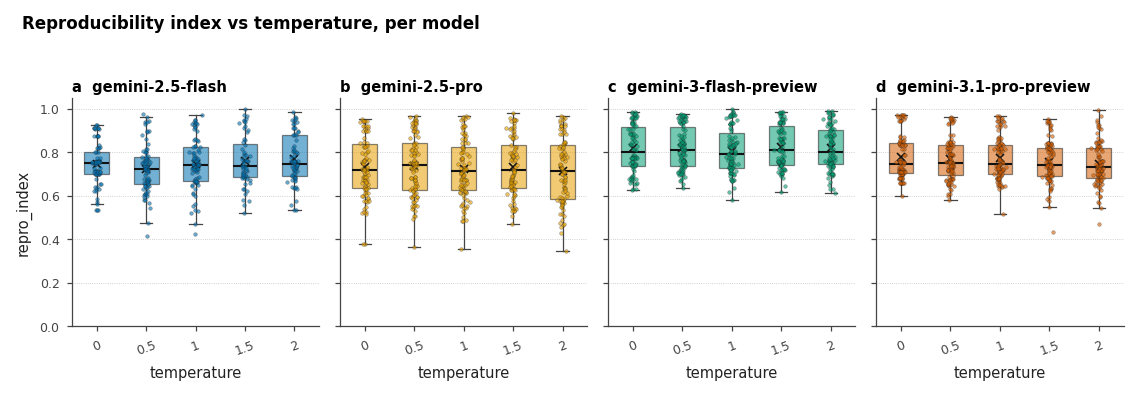

In [14]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(1.9 * len(MODELS), 2.6), sharey=True)
if len(MODELS) == 1:
    axes = [axes]
panel = "abcdefgh"
for i, (ax, m) in enumerate(zip(axes, MODELS)):
    sub = df[df.model == m]
    temps = sorted(sub.temperature.unique())
    data = [sub[sub.temperature == t]["repro_index"].values for t in temps]
    nature_box(ax, data, [f"{t:g}" for t in temps],
               colors=[model_color(m)] * len(temps),
               ymin=0, ymax=1.05, widths=0.5)
    ax.set_title(f"{panel[i]}  {m}", fontsize=7, pad=3)
    ax.set_xlabel("temperature")
axes[0].set_ylabel("repro_index")
fig.suptitle("Reproducibility index vs temperature, per model",
             x=0.02, ha="left", fontsize=8, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


In [15]:
comp_cols = [
    "sources_consumed_ratio",
    "sinks_produced_ratio",
    "resolved_input_ratio",
    "source_to_sink_reachability",
    "lwcc_fraction",
    "src_repro",
    "proc_repro",
    "sink_repro",
]
df.groupby("model")[comp_cols].mean().round(3)

,sources_consumed_ratio,sinks_produced_ratio,resolved_input_ratio,source_to_sink_reachability,lwcc_fraction,src_repro,proc_repro,sink_repro
model,,,,,,,,
gemini-2.5-flash,0.734,0.885,0.895,0.461,0.880,0.521,0.834,0.763
gemini-2.5-pro,0.766,0.969,0.957,0.500,0.831,0.580,0.703,0.666
gemini-3-flash-preview,0.745,0.923,0.999,0.601,0.933,0.552,0.904,0.863
gemini-3.1-pro-preview,0.638,0.977,0.998,0.376,0.895,0.478,0.847,0.800


## 6. Per-paper analysis — variability vs paper size

The 10 ReScience-C papers vary sharply in length (4–34 pages, 3.4 k–22.9 k words). This section pivots the per-run dataframe by paper, joins page / word metadata, and asks two questions:

1. Do **longer** papers produce systematically lower (or higher) reproducibility scores?
2. Is **run-to-run variability** (std across the 10 samples at fixed model × temperature) bigger for longer papers — i.e. does paper size hurt consistency?

Per-paper rows pool over models and temperatures unless the panel says otherwise.

In [16]:
# Paper-size metadata: (pages, words). Keys match the `paper` column in run_timings.csv.
PAPER_META = {
    "2017_04_article.pdf": (4, 3372),
    "2020_26_article.pdf": (8, 3701),
    "2017_01_article.pdf": (15, 6436),
    "2025_03_article.pdf": (20, 8930),
    "2017_08_article.pdf": (11, 9237),
    "2022_30_article.pdf": (18, 9800),
    "2021_34_article.pdf": (28, 13493),
    "2023_17_article.pdf": (24, 14733),
    "2023_15_article.pdf": (30, 16170),
    "2022_38_article.pdf": (34, 22917),
}
meta = (
    pd.DataFrame.from_dict(PAPER_META, orient="index", columns=["n_pages", "n_words"])
    .rename_axis("paper")
    .reset_index()
)
df_p = df.merge(meta, on="paper", how="left")

unmatched = df_p[df_p.n_pages.isna()].paper.unique()
if len(unmatched):
    print("WARN: papers without metadata:", list(unmatched))

# Stable order: shortest paper first.
PAPER_ORDER = (
    meta.sort_values("n_words").paper.tolist()
)
print(f"papers: {len(PAPER_ORDER)}   rows after merge: {len(df_p)}")
meta.assign(label=lambda d: d.paper.str.replace("_article.pdf", "", regex=False)).set_index("label")[["n_pages", "n_words"]]

papers: 10   rows after merge: 1804


,n_pages,n_words
label,,
2017_04,4,3372
2020_26,8,3701
2017_01,15,6436
2025_03,20,8930
2017_08,11,9237
2022_30,18,9800
2021_34,28,13493
2023_17,24,14733
2023_15,30,16170


In [17]:
# Per-paper aggregation: pool over models and temperatures, report mean and std.
per_paper = (
    df_p.groupby("paper")
    .agg(
        n_runs=("repro_index", "count"),
        n_pages=("n_pages", "first"),
        n_words=("n_words", "first"),
        struct_mean=("structural", "mean"),
        struct_std=("structural", "std"),
        content_mean=("content", "mean"),
        content_std=("content", "std"),
        repro_mean=("repro_index", "mean"),
        repro_std=("repro_index", "std"),
        n_source_mean=("n_source", "mean"),
        n_process_mean=("n_process", "mean"),
        n_sink_mean=("n_sink", "mean"),
    )
    .loc[PAPER_ORDER]
    .round(3)
)
per_paper

,n_runs,n_pages,n_words,struct_mean,struct_std,content_mean,content_std,repro_mean,repro_std,n_source_mean,n_process_mean,n_sink_mean
paper,,,,,,,,,,,,
2017_04_article.pdf,196,4,3372,0.778,0.202,0.649,0.124,0.702,0.118,1.434,4.577,1.077
2020_26_article.pdf,184,8,3701,0.767,0.190,0.917,0.056,0.833,0.112,0.908,6.663,1.799
2017_01_article.pdf,192,15,6436,0.711,0.179,0.856,0.100,0.773,0.105,0.406,6.615,4.979
2025_03_article.pdf,150,20,8930,0.765,0.117,0.645,0.108,0.698,0.084,6.613,10.580,11.533
2017_08_article.pdf,188,11,9237,0.888,0.104,0.539,0.071,0.689,0.063,2.261,9.521,12.835
2022_30_article.pdf,167,18,9800,0.819,0.126,0.641,0.088,0.720,0.079,6.964,8.778,12.557
2021_34_article.pdf,179,28,13493,0.688,0.195,0.686,0.158,0.673,0.108,0.626,6.380,3.078
2023_17_article.pdf,185,24,14733,0.958,0.079,0.884,0.050,0.919,0.051,2.000,7.627,6.016
2023_15_article.pdf,188,30,16170,0.907,0.076,0.731,0.054,0.813,0.053,4.000,14.984,10.649


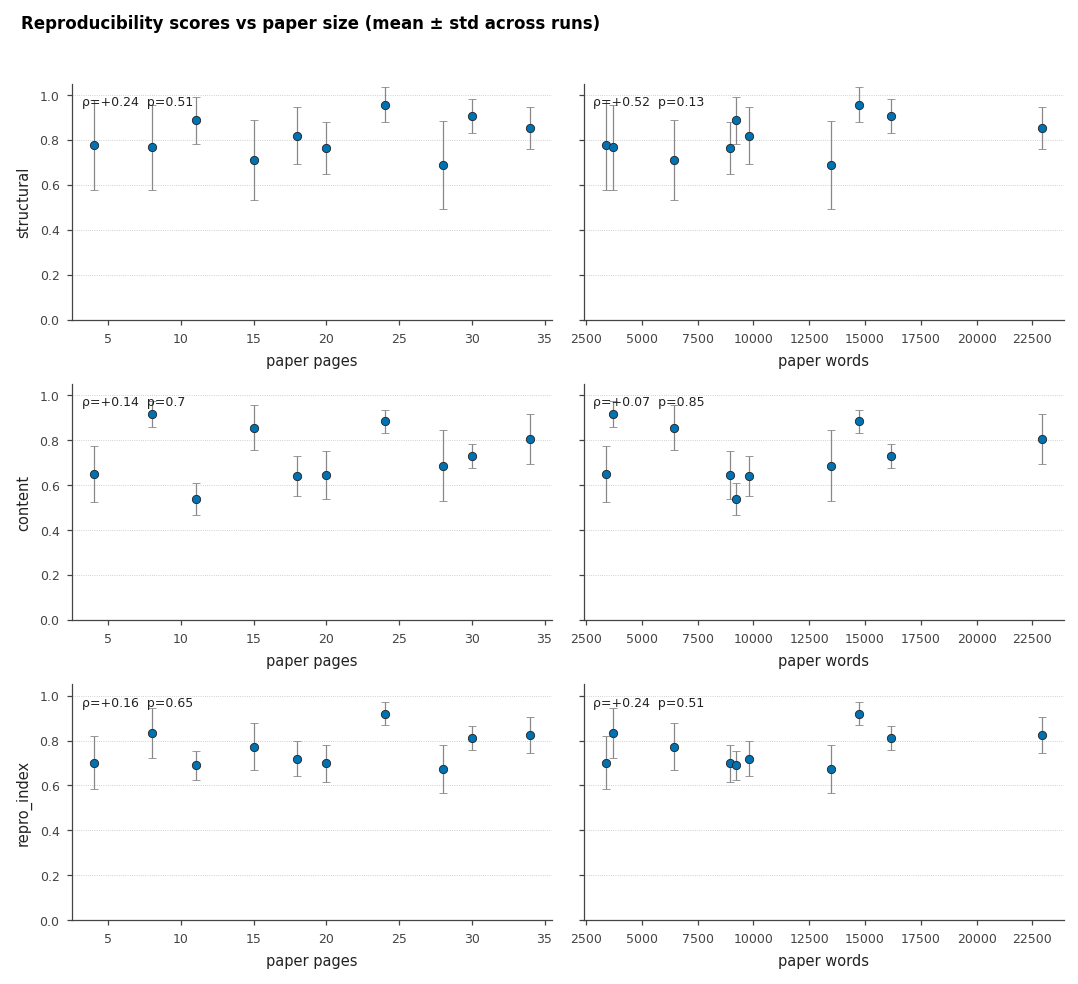

In [18]:
# Reproducibility scores vs paper size (pages and words).
# Each point is one paper, error bar = std over its ~180 runs.
# Spearman rank correlation reported in each panel.
from scipy.stats import spearmanr

SIZE_COLS = [("n_pages", "pages"), ("n_words", "words")]
SCORE_COLS = ["structural", "content", "repro_index"]
MEAN_COL = {"structural": "struct_mean", "content": "content_mean", "repro_index": "repro_mean"}
STD_COL = {"structural": "struct_std", "content": "content_std", "repro_index": "repro_std"}

fig, axes = plt.subplots(len(SCORE_COLS), len(SIZE_COLS),
                         figsize=(7.2, 6.6), sharey="row")
for i, score in enumerate(SCORE_COLS):
    for j, (size_col, size_lbl) in enumerate(SIZE_COLS):
        ax = axes[i, j]
        x = per_paper[size_col].values
        y = per_paper[MEAN_COL[score]].values
        yerr = per_paper[STD_COL[score]].values
        ax.errorbar(x, y, yerr=yerr, fmt="o", color="#0072B2",
                    ecolor="#888", elinewidth=0.6, capsize=2,
                    markersize=4, markeredgecolor="#222", markeredgewidth=0.4)
        rho, pval = spearmanr(x, y)
        ax.text(0.02, 0.95, f"ρ={rho:+.2f}  p={pval:.2g}",
                transform=ax.transAxes, fontsize=6, va="top", color="#222")
        ax.set_xlabel(f"paper {size_lbl}")
        if j == 0:
            ax.set_ylabel(score)
        ax.set_ylim(0, 1.05)
        style_axes(ax)

fig.suptitle("Reproducibility scores vs paper size (mean ± std across runs)",
             x=0.02, ha="left", fontsize=8, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

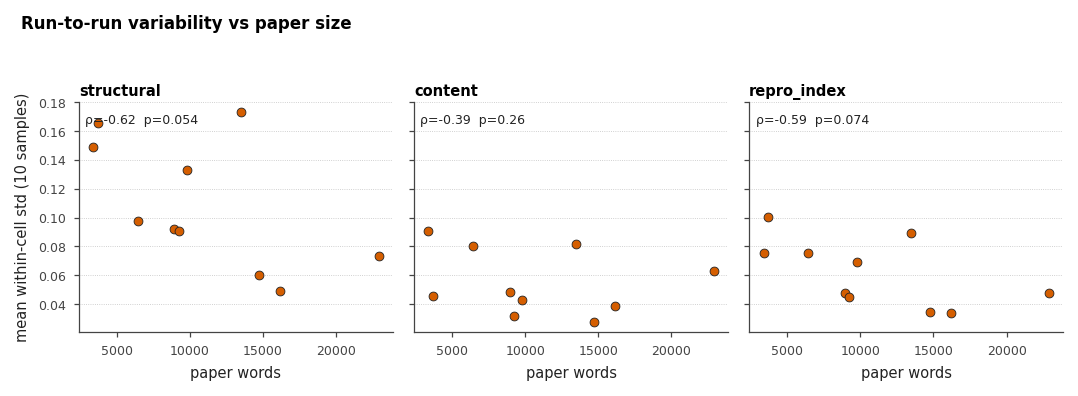

,structural,content,repro_index,n_pages,n_words
paper,,,,,
2017_04_article.pdf,0.149,0.091,0.076,4,3372
2020_26_article.pdf,0.166,0.046,0.100,8,3701
2017_01_article.pdf,0.098,0.080,0.075,15,6436
2025_03_article.pdf,0.092,0.048,0.047,20,8930
2017_08_article.pdf,0.091,0.032,0.045,11,9237
2022_30_article.pdf,0.133,0.043,0.069,18,9800
2021_34_article.pdf,0.173,0.082,0.090,28,13493
2023_17_article.pdf,0.060,0.028,0.034,24,14733
2023_15_article.pdf,0.049,0.039,0.034,30,16170


In [19]:
# Within-cell consistency: std across the 10 samples at each (paper, model, temperature).
# Then average those stds per paper. Higher = more sensitive to seed/temperature.
within = (
    df_p.groupby(["paper", "model", "temperature"])[SCORE_COLS]
    .std()
    .reset_index()
    .merge(meta, on="paper", how="left")
)
within_paper = (
    within.groupby("paper")[SCORE_COLS]
    .mean()
    .merge(meta, left_index=True, right_on="paper")
    .set_index("paper")
    .loc[PAPER_ORDER]
)

fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), sharey=True)
for ax, score in zip(axes, SCORE_COLS):
    x = within_paper["n_words"].values
    y = within_paper[score].values
    ax.scatter(x, y, s=18, color="#D55E00",
               edgecolor="#222", linewidth=0.4, zorder=3)
    rho, pval = spearmanr(x, y)
    ax.text(0.02, 0.95, f"ρ={rho:+.2f}  p={pval:.2g}",
            transform=ax.transAxes, fontsize=6, va="top", color="#222")
    ax.set_xlabel("paper words")
    ax.set_title(score, fontsize=7, pad=3)
    style_axes(ax)
axes[0].set_ylabel("mean within-cell std (10 samples)")
fig.suptitle("Run-to-run variability vs paper size",
             x=0.02, ha="left", fontsize=8, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

within_paper.round(3)

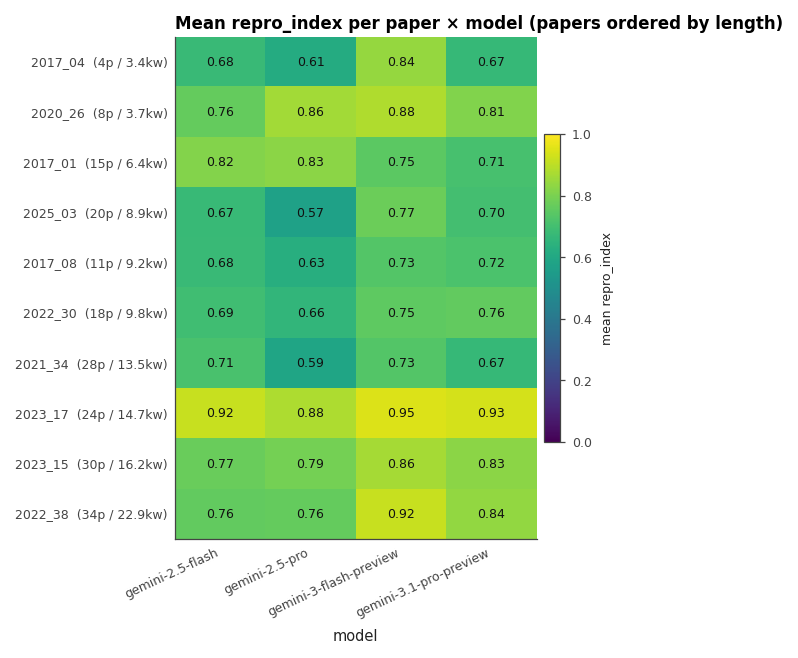

model,gemini-2.5-flash,gemini-2.5-pro,gemini-3-flash-preview,gemini-3.1-pro-preview
paper,,,,
2017_04_article.pdf,0.678,0.613,0.842,0.671
2020_26_article.pdf,0.762,0.862,0.880,0.812
2017_01_article.pdf,0.816,0.828,0.746,0.710
2025_03_article.pdf,0.673,0.573,0.774,0.703
2017_08_article.pdf,0.676,0.627,0.734,0.717
2022_30_article.pdf,0.692,0.658,0.751,0.760
2021_34_article.pdf,0.714,0.588,0.733,0.671
2023_17_article.pdf,0.915,0.879,0.947,0.935
2023_15_article.pdf,0.772,0.792,0.864,0.826


In [20]:
# Per-paper × model heatmap of mean repro_index, papers ordered by length.
heat = (
    df_p.groupby(["paper", "model"])["repro_index"]
    .mean()
    .unstack("model")
    .loc[PAPER_ORDER]
)
labels = [p.replace("_article.pdf", "") for p in heat.index]

fig, ax = plt.subplots(figsize=(0.55 * len(MODELS) + 2.0, 0.32 * len(heat) + 1.2))
im = ax.imshow(heat.values, cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=25, ha="right", fontsize=6)
ax.set_yticks(np.arange(len(heat)))
ax.set_yticklabels(
    [f"{lbl}  ({per_paper.loc[p, 'n_pages']:.0f}p / {per_paper.loc[p, 'n_words']/1000:.1f}kw)"
     for lbl, p in zip(labels, heat.index)],
    fontsize=6,
)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if pd.isna(v):
            continue
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="#fff" if v < 0.55 else "#111", fontsize=6)
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("mean repro_index", fontsize=6)
cbar.ax.tick_params(labelsize=6)
ax.set_title("Mean repro_index per paper × model (papers ordered by length)",
             fontsize=8, pad=4, loc="left")
ax.set_xlabel("model")
ax.tick_params(axis="both", which="both", length=0)
plt.tight_layout()
plt.show()

heat.round(3)

### 6.1 Repro index by paper × model

Three views of the same `(paper, model)` cell:

- **Table** — mean ± std of `repro_index` (std pooled over the 5 temperatures × 10 samples ≈ 50 runs per cell).
- **Faceted boxplots** — one panel per paper (ordered shortest → longest), showing the per-run distribution split by model, so model robustness across paper lengths is visible.
- **Consistency table** — within-cell std (avg over temperatures of the 10-sample std) per `(paper, model)`. Lower = more reproducible at fixed prompt.

In [21]:
# Table: mean ± std of repro_index per (paper, model). Papers ordered shortest -> longest.
pm = (
    df_p.groupby(["paper", "model"])["repro_index"]
    .agg(["mean", "std", "count"])
    .round(3)
)
pm_mean = pm["mean"].unstack("model").loc[PAPER_ORDER]
pm_std = pm["std"].unstack("model").loc[PAPER_ORDER]
pm_table = pm_mean.copy()
for m in pm_mean.columns:
    pm_table[m] = pm_mean[m].map("{:.3f}".format) + " ± " + pm_std[m].map("{:.3f}".format)
pm_table.index = [f"{p.replace('_article.pdf', '')}  ({per_paper.loc[p, 'n_pages']:.0f}p)"
                  for p in pm_table.index]
pm_table

model,gemini-2.5-flash,gemini-2.5-pro,gemini-3-flash-preview,gemini-3.1-pro-preview
2017_04 (4p),0.678 ± 0.108,0.613 ± 0.085,0.842 ± 0.071,0.671 ± 0.055
2020_26 (8p),0.762 ± 0.091,0.862 ± 0.111,0.880 ± 0.113,0.812 ± 0.095
2017_01 (15p),0.816 ± 0.117,0.828 ± 0.135,0.746 ± 0.045,0.710 ± 0.038
2025_03 (20p),0.673 ± 0.064,0.573 ± 0.047,0.774 ± 0.070,0.703 ± 0.022
2017_08 (11p),0.676 ± 0.056,0.627 ± 0.040,0.734 ± 0.052,0.717 ± 0.042
2022_30 (18p),0.692 ± 0.081,0.658 ± 0.070,0.751 ± 0.062,0.760 ± 0.059
2021_34 (28p),0.714 ± 0.122,0.588 ± 0.113,0.733 ± 0.063,0.671 ± 0.071
2023_17 (24p),0.915 ± 0.029,0.879 ± 0.035,0.947 ± 0.057,0.935 ± 0.048
2023_15 (30p),0.772 ± 0.048,0.792 ± 0.034,0.864 ± 0.039,0.826 ± 0.041
2022_38 (34p),0.761 ± 0.068,0.763 ± 0.065,0.915 ± 0.041,0.839 ± 0.026


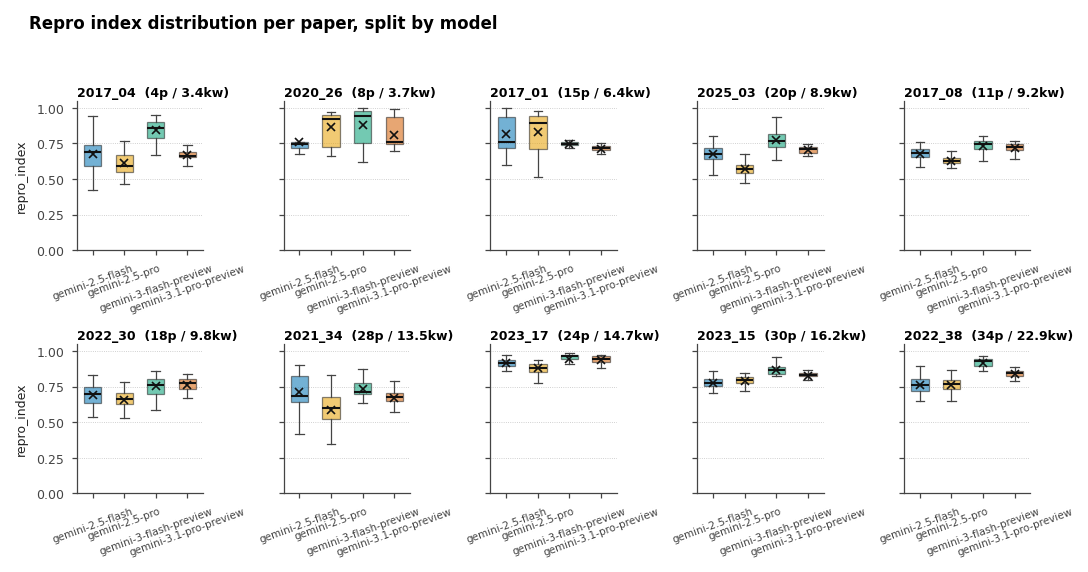

In [22]:
# Faceted boxplots: one panel per paper (ordered shortest -> longest),
# distribution of repro_index split by model.
n = len(PAPER_ORDER)
ncol = 5
nrow = math.ceil(n / ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(7.2, 1.9 * nrow), sharey=True)
axes = np.array(axes).reshape(nrow, ncol)
colors = [model_color(m) for m in MODELS]

for idx, paper in enumerate(PAPER_ORDER):
    ax = axes[idx // ncol, idx % ncol]
    sub = df_p[df_p.paper == paper]
    data = [sub[sub.model == m]["repro_index"].values for m in MODELS]
    nature_box(ax, data, MODELS, colors=colors, ymin=0, ymax=1.05,
               widths=0.55, jitter=False)
    short = paper.replace("_article.pdf", "")
    ax.set_title(f"{short}  ({per_paper.loc[paper, 'n_pages']:.0f}p / "
                 f"{per_paper.loc[paper, 'n_words']/1000:.1f}kw)",
                 fontsize=6, pad=2)
    ax.tick_params(axis="x", labelsize=5)
    ax.tick_params(axis="y", labelsize=6)
    if idx % ncol == 0:
        ax.set_ylabel("repro_index", fontsize=6)

# blank any leftover axes
for k in range(n, nrow * ncol):
    axes[k // ncol, k % ncol].axis("off")

fig.suptitle("Repro index distribution per paper, split by model",
             x=0.02, ha="left", fontsize=8, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

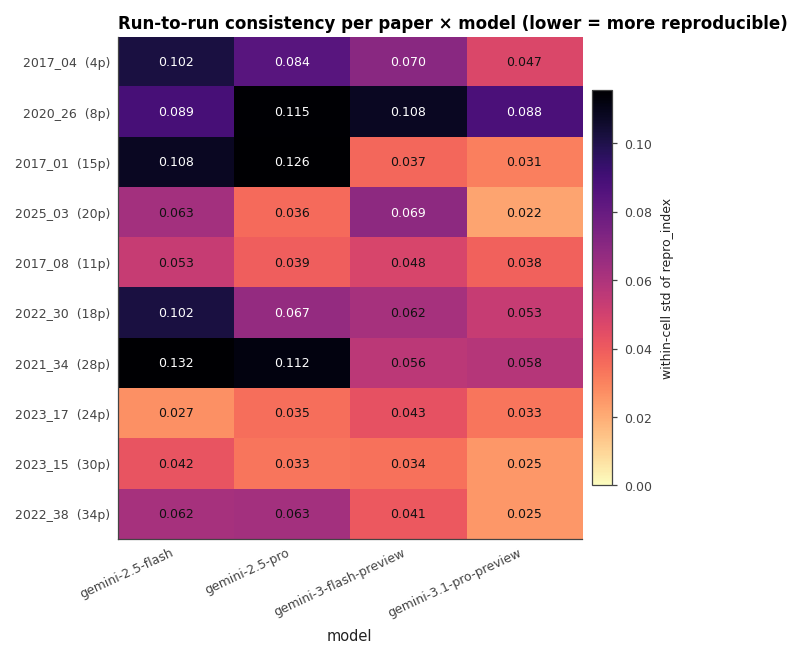

model,gemini-2.5-flash,gemini-2.5-pro,gemini-3-flash-preview,gemini-3.1-pro-preview
2017_04 (4p),0.102,0.084,0.070,0.047
2020_26 (8p),0.089,0.115,0.108,0.088
2017_01 (15p),0.108,0.126,0.037,0.031
2025_03 (20p),0.063,0.036,0.069,0.022
2017_08 (11p),0.053,0.039,0.048,0.038
2022_30 (18p),0.102,0.067,0.062,0.053
2021_34 (28p),0.132,0.112,0.056,0.058
2023_17 (24p),0.027,0.035,0.043,0.033
2023_15 (30p),0.042,0.033,0.034,0.025
2022_38 (34p),0.062,0.063,0.041,0.025


In [23]:
# Within-cell consistency per (paper, model): for each (paper, model, temperature)
# compute std of repro_index across the 10 samples, then average over temperatures.
within_pm = (
    df_p.groupby(["paper", "model", "temperature"])["repro_index"]
    .std()
    .groupby(["paper", "model"])
    .mean()
    .unstack("model")
    .loc[PAPER_ORDER]
    .round(3)
)
within_pm.index = [f"{p.replace('_article.pdf', '')}  ({per_paper.loc[p, 'n_pages']:.0f}p)"
                   for p in within_pm.index]

# Heatmap of consistency: lower = more reproducible.
fig, ax = plt.subplots(figsize=(0.55 * len(MODELS) + 2.4, 0.32 * len(within_pm) + 1.2))
arr = within_pm.values
vmax = np.nanpercentile(arr, 95) if np.isfinite(arr).any() else 1.0
im = ax.imshow(arr, cmap="magma_r", vmin=0, vmax=vmax, aspect="auto")
ax.set_xticks(np.arange(within_pm.shape[1]))
ax.set_xticklabels(within_pm.columns, rotation=25, ha="right", fontsize=6)
ax.set_yticks(np.arange(within_pm.shape[0]))
ax.set_yticklabels(within_pm.index, fontsize=6)
for i in range(within_pm.shape[0]):
    for j in range(within_pm.shape[1]):
        v = arr[i, j]
        if pd.isna(v):
            continue
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color="#fff" if v > vmax * 0.55 else "#111", fontsize=6)
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("within-cell std of repro_index", fontsize=6)
cbar.ax.tick_params(labelsize=6)
ax.set_title("Run-to-run consistency per paper × model (lower = more reproducible)",
             fontsize=8, pad=4, loc="left")
ax.set_xlabel("model")
ax.tick_params(axis="both", which="both", length=0)
plt.tight_layout()
plt.show()

within_pm